# Digital Twin for HAADF and EDS



### Quick Start Code Cell

In [1]:
import subprocess
import time
import os
import tango
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DB_HOST = "localhost"
DB_PORT = 9000
server_list = [("stage", "asyncroscopy.hardware.STAGE"),
                     ("scan", "asyncroscopy.hardware.SCAN"),
                     ("eds", "asyncroscopy.detectors.EDS")]
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR = os.path.dirname(os.getcwd())
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"
env = {**os.environ, "TANGO_HOST": f"{DB_HOST}:{DB_PORT}"}
processes = {}

def popen(cmd):
    return subprocess.Popen(cmd, env=env, cwd=PROJECT_DIR, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

def wait_for_device(name, timeout=60, interval=1):
    print(f"  Waiting for {name}...", end="", flush=True)
    start = time.time()
    while time.time() - start < timeout:
        try:
            tango.DeviceProxy(name).ping()
            print(f" ✅ ready ({time.time()-start:.1f}s)"); return True
        except:
            print(".", end="", flush=True); time.sleep(interval)
    print(f" ❌ timed out after {timeout}s"); return False

def check_processes(*names):
    for name in names:
        p = processes[name]
        print(f"\n─── {name} (PID {p.pid}) ───\n  Running: {p.poll() is None}")
        for label, fd in [("STDOUT", p.stdout), ("STDERR", p.stderr)]:
            try: print(f"  {label}: {fd.read1(4096).decode() or '(empty)'}")
            except: print(f"  {label}: (no output yet)")

# Kill old processes (if any)
print("Clearing old processes...")
for cmd in [f"kill -9 $(lsof -t -i:{DB_PORT}) 2>/dev/null || true",
            *[f"pkill -f '{module.split('.')[-1]} {name}_instance' 2>/dev/null || true"
              for name, module in server_list],
            "pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true"]:
    subprocess.run(cmd, shell=True)
time.sleep(2)

# Start DB
print(f"Project dir: {PROJECT_DIR}\nStarting Tango Database...")
processes["database"] = popen(["uv", "run", "python", "-m", "tango.databaseds.database", "2"])
print("  Waiting for database...", end="", flush=True)
for _ in range(30):
    try: tango.Database(DB_HOST, DB_PORT); print(" ✅ ready"); break
    except: print(".", end="", flush=True); time.sleep(1)

# Register devices
print("Registering devices...")
r = subprocess.run(["uv", "run", "scripts/2_register_devices.py"], env=env, cwd=PROJECT_DIR, capture_output=True, text=True)
print(r.stdout.strip())
if r.returncode != 0:
    print("ERROR:", r.stderr); raise RuntimeError("Device registration failed — stopping here.")

# Start servers
print("Starting device servers...")
for name, module in server_list:
    processes[name] = popen(["uv", "run", "python", "-m", module, f"{name}_instance"])

if not all(wait_for_device(f"test/{d}/1") for d in ["stage", "scan", "eds"]):
    raise RuntimeError("Stage/Scan/EDS server failed.")

print("Starting Microscope...")
processes["microscope"] = popen(["uv", "run", "python", "-m", "asyncroscopy.ThermoMicroscope", "microscope_instance"])
if not wait_for_device("test/microscope/1"):
    print("\n⚠️  Debug info:"); check_processes("microscope")
    raise RuntimeError("Microscope server failed — see debug info above.")

print("\n✅ All servers ready!")

Clearing old processes...
Project dir: /Users/austin/Documents/GitHub/asyncroscopy
Starting Tango Database...
  Waiting for database.... ✅ ready
Registering devices...
Connected: stingray-zm68g.device.utk.edu:9000

  registered: test/scan/1
  registered: test/camera/1
  registered: test/eds/1
  registered: test/stage/1
  registered: test/microscope/1
  property:   scan_device_address = test/scan/1
  property:   camera_device_address = test/camera/1
  property:   eds_device_address = test/eds/1
  property:   stage_device_address = test/stage/1

Done!
Starting device servers...
  Waiting for test/stage/1.... ✅ ready (1.0s)
  Waiting for test/scan/1... ✅ ready (0.0s)
  Waiting for test/eds/1... ✅ ready (0.0s)
Starting Microscope...
  Waiting for test/microscope/1.... ✅ ready (1.0s)

✅ All servers ready!


## 1. Connect to devices

In [3]:
# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:9000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"

# list devices on DB
db = tango.Database()
devices = db.get_device_name("*", "*")
print("Devices registered in Tango DB:\n")
for d in devices:
    print(d)

Devices registered in Tango DB:

asyncroscopy/detector/haadf
asyncroscopy/microscope/thermo
dserver/CAMERA/camera_instance
dserver/DataBaseds/2
dserver/DetectorServer/detectors
dserver/EDS/eds_instance
dserver/HAADF/haadf_instance
dserver/MicroscopeServer/microscope
dserver/SCAN/scan_instance
dserver/STAGE/eds_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
test/camera/1
test/eds/1
test/microscope/1
test/scan/1
test/stage/1


In [4]:
scan = tango.DeviceProxy("test/scan/1")
mic = tango.DeviceProxy("test/microscope/1")

scan.set_timeout_millis(120_000)
mic.set_timeout_millis(120_000)

In [5]:
## helper funcs.
def get_image(dwell=10e-6, imsize=512, auto_focus=True):
    scan.dwell_time = dwell
    scan.imsize  = imsize
    if auto_focus:
        mic.auto_focus()
    json_meta, raw_bytes = mic.get_scanned_image()
    metadata  = dict(json.loads(json_meta))
    image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

    return image, metadata

### Begin

Stage position: [-7.5178350e-06  2.1119165e-05 -1.0023138e-04  6.9810711e-02
  0.0000000e+00]


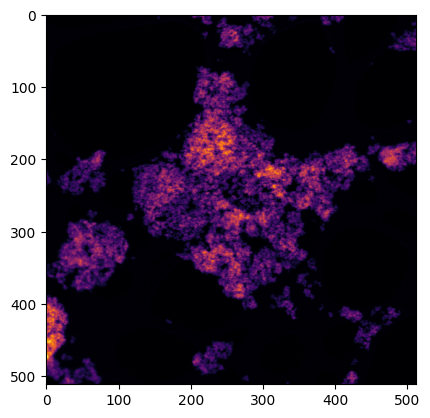

In [23]:
# Get image
starting_image, meta = get_image(dwell=1e-6)
plt.figure()
plt.imshow(starting_image, cmap='inferno')

# Get Stage
starting_position = mic.get_stage()
print('Stage position:', starting_position)

### Okay, but with drift correction

In [19]:
fov = mic.get_fov()
pixel_size = fov / meta['shape'][0]

Estimated drift in pixels (dy, dx):
step 0: (0, 0)
step 1: (np.int64(24), np.int64(20))
step 2: (np.int64(4), np.int64(0))
step 3: (np.int64(-1), np.int64(1))
step 4: (np.int64(-6), np.int64(0))

Applied stage corrections (dx_stage, dy_stage):
step 0: (0.0, 0.0)
step 1: (np.float64(-2.914670060860658e-08), np.float64(-3.4976040730327895e-08))
step 2: (np.float64(0.0), np.float64(-5.829340121721316e-09))
step 3: (np.float64(-1.457335030430329e-09), np.float64(1.457335030430329e-09))
step 4: (np.float64(0.0), np.float64(8.744010182581974e-09))


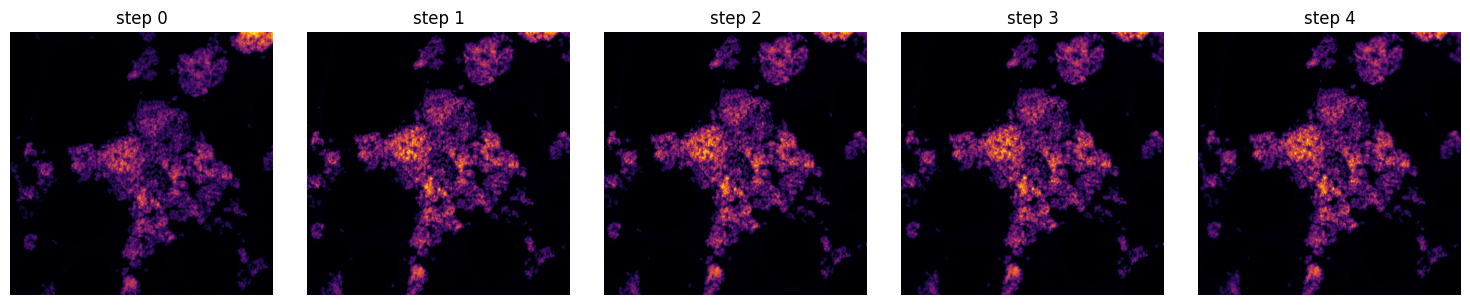

In [24]:
from scipy.signal import fftconvolve

def phase_corr_shift(img_ref, img_new, upsample=False):
    """
    Estimate translational shift between two images.
    Returns (dy, dx) in pixels such that shifting img_new by (-dy, -dx)
    aligns it to img_ref.
    """
    a = img_ref.astype(np.float32)
    b = img_new.astype(np.float32)

    # remove mean and normalize a bit for robustness
    a = a - np.mean(a)
    b = b - np.mean(b)

    # optional: normalize by std to reduce contrast sensitivity
    a_std = np.std(a)
    b_std = np.std(b)
    if a_std > 0:
        a = a / a_std
    if b_std > 0:
        b = b / b_std

    # FFT cross-correlation
    corr = fftconvolve(a, b[::-1, ::-1], mode='same')
    maxpos = np.unravel_index(np.argmax(corr), corr.shape)

    cy, cx = np.array(corr.shape) // 2
    dy = maxpos[0] - cy
    dx = maxpos[1] - cx

    return dy, dx


def pixels_to_stage_shift(dx_pix, dy_pix, pixel_size_x, pixel_size_y):
    """
    Convert image pixel shift to stage correction in stage units.
    You must check sign convention on your microscope.

    Returns (stage_dx, stage_dy)
    """
    stage_dx = -dx_pix * pixel_size_x
    stage_dy = -dy_pix * pixel_size_y
    return stage_dx, stage_dy


# --- user parameters ---
step_size = 3  # degrees
n_steps = 5


images = []
positions = []
drift_pixels = []
stage_corrections = []

# initial reference
current_position = starting_position.copy()
mic.move_stage(current_position)
ref_im, ref_met = get_image(dwell=1e-6)

images.append(ref_im)
positions.append(current_position.copy())
drift_pixels.append((0, 0))
stage_corrections.append((0.0, 0.0))

for i in range(1, n_steps):
    # 1) nominal next tilt position
    new_position = current_position.copy()
    new_position[3] = starting_position[3] + step_size * i
    mic.move_stage(new_position)

    # 2) acquire after tilt
    im_raw, met = get_image(dwell=1e-6)

    # 3) estimate drift relative to previous corrected image
    dy_pix, dx_pix = phase_corr_shift(ref_im, im_raw)
    drift_pixels.append((dy_pix, dx_pix))

    # 4) convert drift to stage correction
    stage_dx, stage_dy = pixels_to_stage_shift(
        dx_pix, dy_pix,
        pixel_size_x=pixel_size,
        pixel_size_y=pixel_size
    )
    stage_corrections.append((stage_dx, stage_dy))

    # 5) apply correction
    corrected_position = new_position.copy()
    corrected_position[0] -= stage_dx
    corrected_position[1] -= stage_dy
    mic.move_stage(corrected_position)

    # 6) reacquire corrected image
    im_corr, met_corr = get_image(dwell=1e-6)

    images.append(im_corr)
    positions.append(corrected_position.copy())

    # update reference for next step
    ref_im = im_corr
    current_position = corrected_position.copy()

# plot
fig, ax = plt.subplots(1, n_steps, figsize=(3 * n_steps, 3), sharex=True, sharey=True)
for i in range(n_steps):
    ax[i].imshow(images[i].T, cmap='inferno')
    ax[i].set_title(f"step {i}")
    ax[i].axis('off')
fig.tight_layout()

print("Estimated drift in pixels (dy, dx):")
for i, d in enumerate(drift_pixels):
    print(f"step {i}: {d}")

print("\nApplied stage corrections (dx_stage, dy_stage):")
for i, c in enumerate(stage_corrections):
    print(f"step {i}: {c}")